In [1]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

<Axes: xlabel='time'>

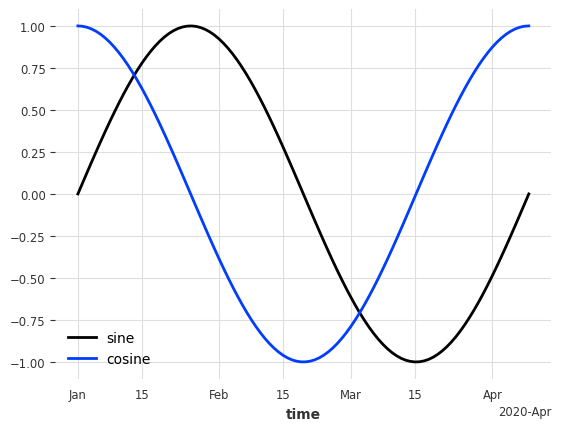

In [3]:
from darts import TimeSeries
from darts.utils.utils import generate_index

x = np.linspace(0, 2*np.pi, 100)
sine_vals = np.sin(x)
cosine_vals = np.cos(x)

dates = generate_index("2020-01-01", length=len(x), freq="D")

df = pd.DataFrame({"sine": sine_vals, "cosine": cosine_vals, "time": dates})

series = TimeSeries.from_dataframe(df, time_col="time")
series.plot()

,Month,#Passengers
0,1960-08-01,606.0
1,1960-09-01,508.0
2,1960-10-01,461.0
3,1960-11-01,390.0
4,1960-12-01,432.0


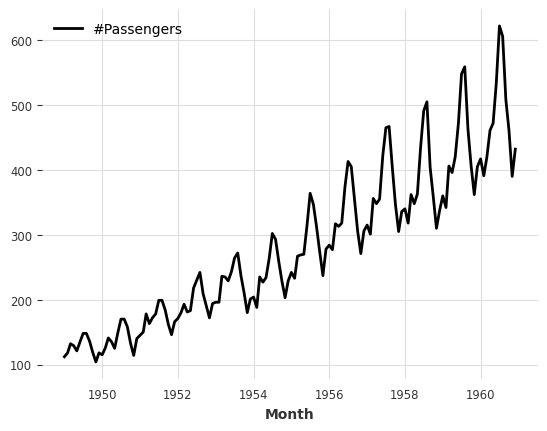

In [4]:
from darts.datasets import AirPassengersDataset

series = AirPassengersDataset().load()
series.plot()

# export TimeSeries to pandas dataframe
series[-5:].to_dataframe(backend="pandas", time_as_index=False)


<Axes: xlabel='Month'>

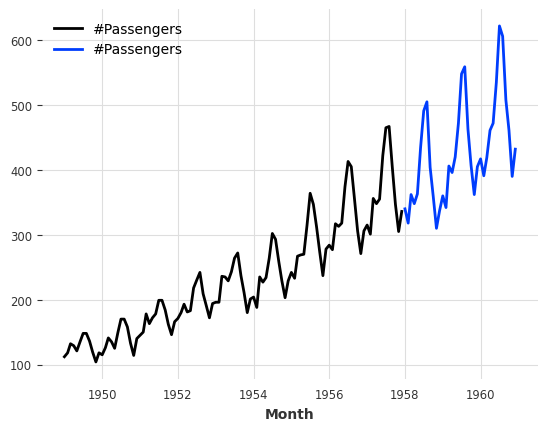

In [5]:
# splitting fraction of time series
series1, series2 = series.split_after(0.75)
series1.plot()
series2.plot()


<Axes: xlabel='Month'>

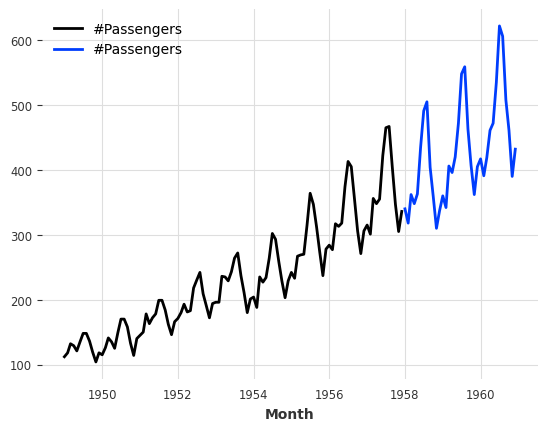

In [6]:
# slicing time series
series1, series2 = series[:-36], series[-36:]
series1.plot()
series2.plot()


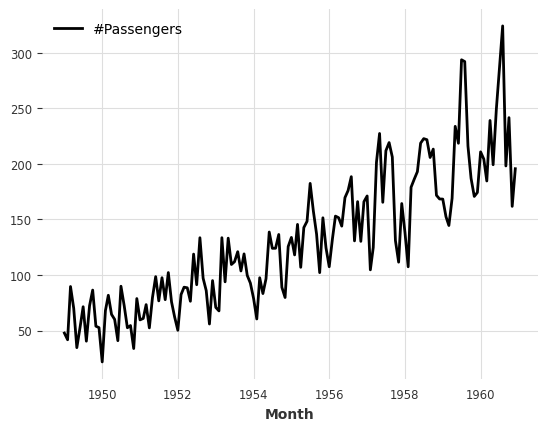

In [7]:
# arithmetic operations
series_noise = TimeSeries.from_times_and_values(series.time_index, np.random.randn(len(series)))
(series / 2 + 20*series_noise - 10).plot();

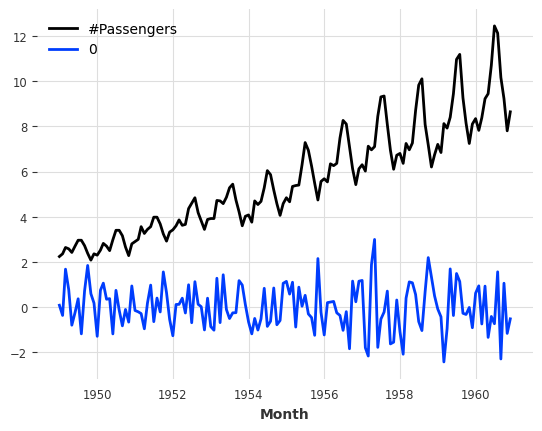

In [8]:
# stack adds an additional TimeSeries component to make comparing multivariate TimeSeries' easier
(series / 50).stack(series_noise).plot();

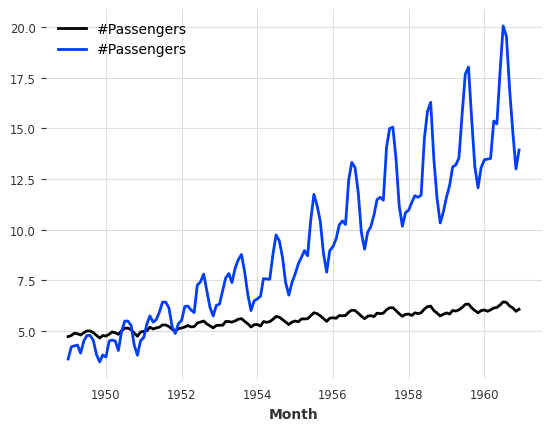

In [9]:
# map operation
series.map(np.log).plot();
# map on both timestamps and values with lambda
series.map(lambda ts, x: x / ts.days_in_month).plot();

<Axes: xlabel='time'>

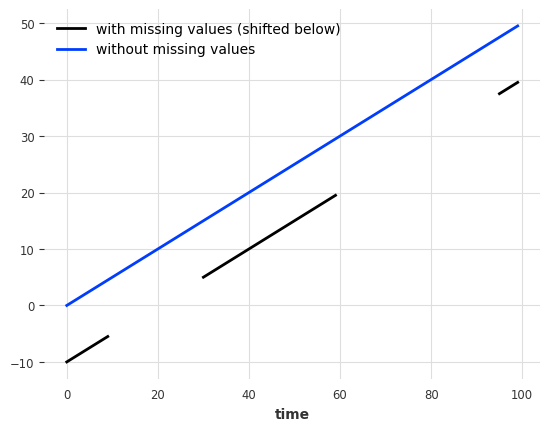

In [10]:
from darts.utils.missing_values import fill_missing_values

values = np.arange(50, step=0.5)
values[10:30] = np.nan
values[60:95] = np.nan
series_ = TimeSeries.from_values(values)

(series_ - 10).plot(label="with missing values (shifted below)")
fill_missing_values(series_).plot(label="without missing values")

<Axes: xlabel='Month'>

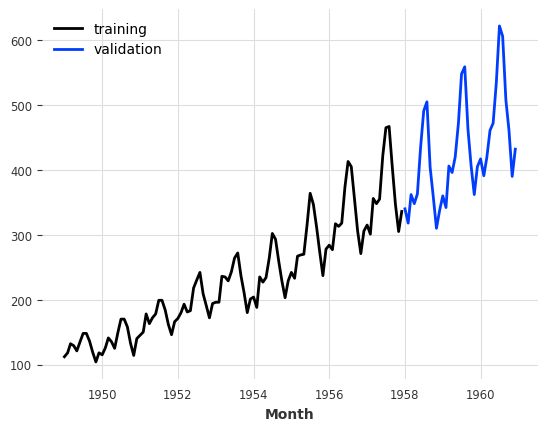

In [11]:
# split series into 'training' and 'validation' sets
train, val = series.split_before(pd.Timestamp("19580101"))
train.plot(label="training")
val.plot(label="validation")

<Axes: xlabel='Month'>

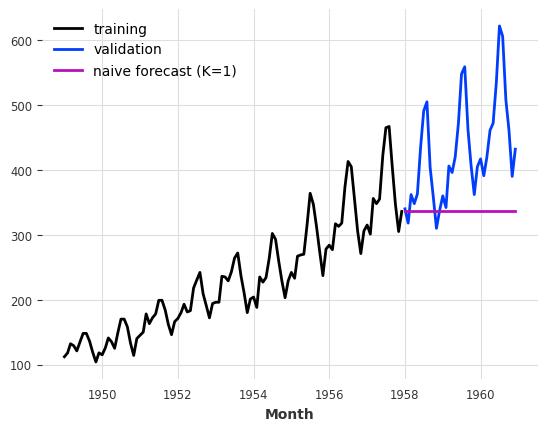

In [12]:
from darts.models import NaiveSeasonal

# K=1 model is just a constant against the last data point in train dataset
naive_model = NaiveSeasonal(K=1)
naive_model.fit(train)
naive_forecast = naive_model.predict(36)

train.plot(label="training")
val.plot(label="validation")
naive_forecast.plot(label="naive forecast (K=1)")

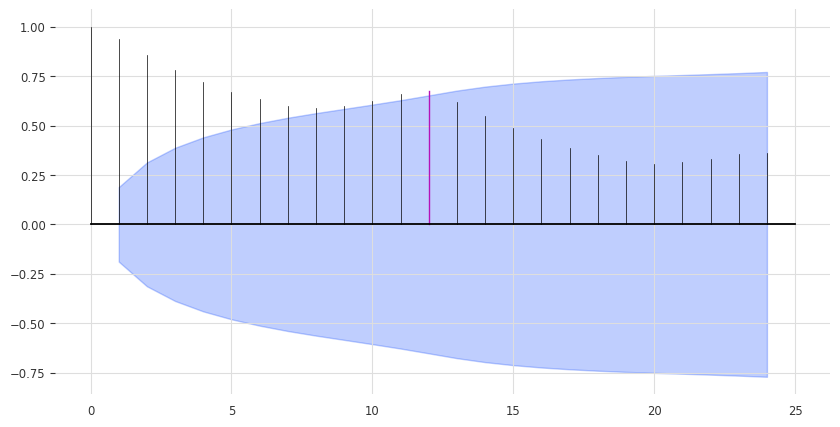

In [13]:
from darts.utils.statistics import check_seasonality, plot_acf

plot_acf(train, m=12, alpha=0.05, max_lag=24)

In [14]:
 # check seasonality for various periods m
 for m in range(2, 25):
     is_seasonal, period = check_seasonality(train, m=m, alpha=0.05)
     if is_seasonal:
         print(f"There is seasonality of order {period}.")

There is seasonality of order 12.


<Axes: xlabel='Month'>

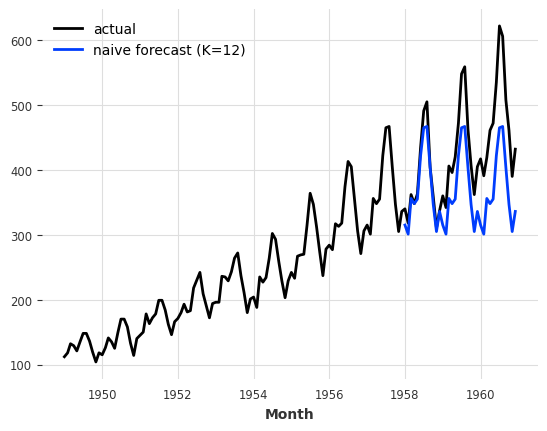

In [15]:
# retrain using seasonality of K=12
seasonal_model = NaiveSeasonal(K=12)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(36)

series.plot(label="actual")
seasonal_forecast.plot(label="naive forecast (K=12)")

<Axes: xlabel='Month'>

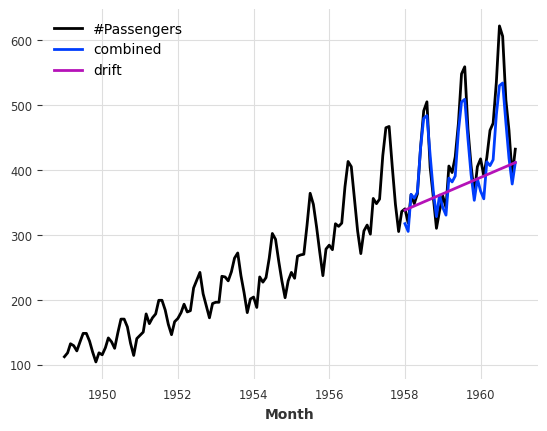

In [16]:
# seems to accurately find the seasonality, missing the trend. use NaiveDrift model to capture the trend
from darts.models import NaiveDrift

drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(36)

combined_forecast = drift_forecast + seasonal_forecast - train.last_value()

series.plot()
combined_forecast.plot(label="combined")
drift_forecast.plot(label="drift")

In [17]:
# naive baseline models creates a model to try and beat
# we calculate the error of the baseline model to get a metric to compare models against

# in practice, there are good reasons to avoid Mean Absolute Percentage Error but is used here for
# explanatory purposes
from darts.metrics import mape
print(
    f"Mean absolute percentage error for the combined naive drift + seasonal: {mape(series, combined_forecast):.2f}%s"
)

Mean absolute percentage error for the combined naive drift + seasonal: 5.66%s


In [18]:
# dart is designed to make it easy to train and validate multiple models in a consistent way
from darts.models import AutoARIMA, ExponentialSmoothing, Theta

def eval_model(model):
    model.fit(train, )
    forecast = model.predict(len(val))
    print(f"model {model} obtains MAPE: {mape(val, forecast):.2f}%")

eval_model(AutoARIMA())
eval_model(ExponentialSmoothing())
eval_model(Theta())


model AutoARIMA() obtains MAPE: 12.70%
model ExponentialSmoothing() obtains MAPE: 5.11%
model Theta() obtains MAPE: 8.15%


In [19]:
# fine tuning Theta method
thetas = 2 - np.linspace(-10, 10, 50)

best_mape = float("inf")
best_theta = 0
for theta in thetas:
    model = Theta(theta)
    model.fit(train)
    pred_theta = model.predict(len(val))
    res = mape(val, pred_theta)

    if res < best_mape:
        best_mape = res
        best_theta = theta

best_theta_model = Theta(best_theta)
best_theta_model.fit(train)
pred_best_theta = best_theta_model.predict(len(val))

print(f"Lowest MAPE is: {mape(val, pred_best_theta):.2f}, with theta = {best_theta}.")

Lowest MAPE is: 4.40, with theta = -3.5102040816326543.


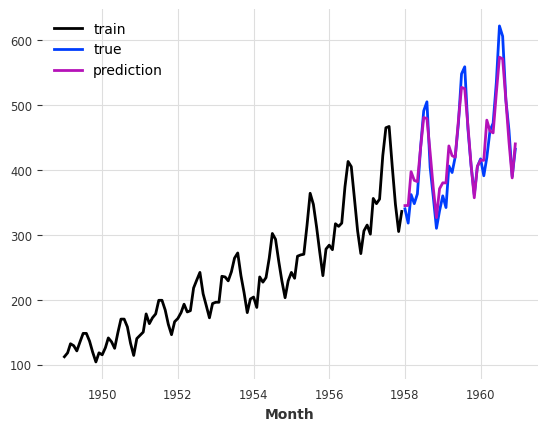

In [20]:
train.plot(label="train")
val.plot(label="true")/
pred_best_theta.plot(label="prediction");

historical forecasts:   0%|          | 0/58 [00:00<?, ?it/s]

MAPE = 7.99%


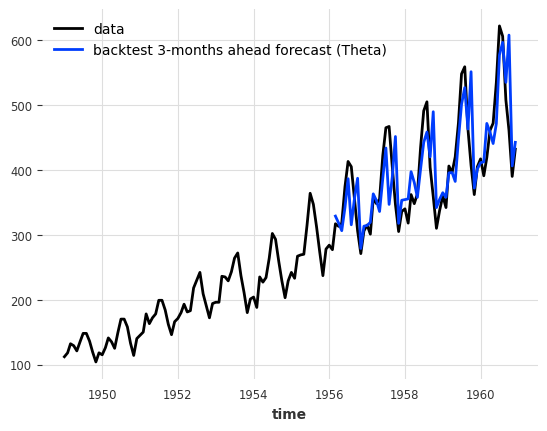

In [21]:
# fine-tuned model performs well on validation dataset, but darts has a historical_forecasts() function
# that lets us test how the model would perform if the next 3 years of data trickled in each month.
# This lets us simulate a real-world stream of time-series data that retrains after each timestep.

hfc_params = {
    "series" : series,
    "start" : pd.Timestamp("1956-01-01"),
    # this determines how far into the future the model is trying to predict in timestep units, here 3
    # months. training data grows after each additional data point, but the forecast window remains the
    # same.
    "forecast_horizon": 3,
    "verbose": True,
}
                                                               # ** unpacks the dict into keywords
historical_fcast_theta = best_theta_model.historical_forecasts(last_points_only=True, **hfc_params)
series.plot(label="data")
historical_fcast_theta.plot(label="backtest 3-months ahead forecast (Theta)")
print(f"MAPE = {mape(series, historical_fcast_theta):.2f}%")

historical forecasts:   0%|          | 0/20 [00:00<?, ?it/s]

MAPE = 5.61%


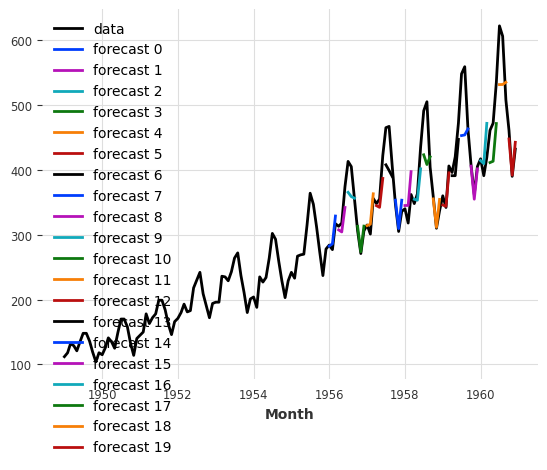

In [22]:
from darts import concatenate

# stride parameter is the number of timesteps between consecutive predictions, controlling the frequency of testing
historical_fcast_theta_all = best_theta_model.historical_forecasts(last_points_only=False, stride=3, **hfc_params)

series.plot(label="data")
for idx, hfc in enumerate(historical_fcast_theta_all):
    hfc.plot(label=f"forecast {idx}")

historical_fcast_theta_all = concatenate(historical_fcast_theta_all, axis=0)
print(f"MAPE = {mape(series, historical_fcast_theta_all):.2f}%")

historical forecasts:   0%|          | 0/58 [00:00<?, ?it/s]

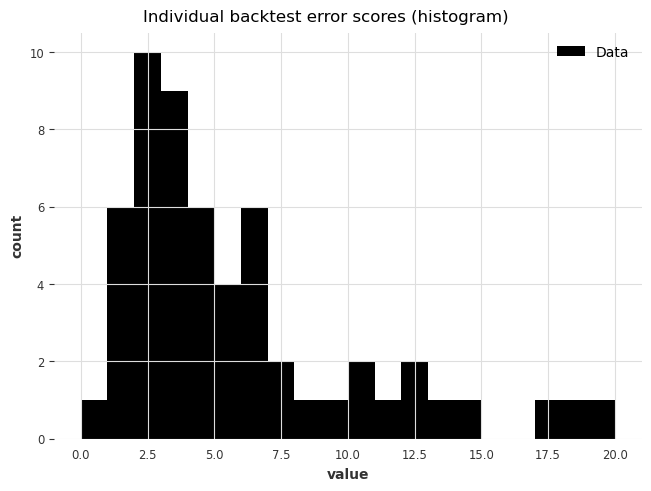

In [23]:
from darts.utils.statistics import plot_hist

best_theta_model = Theta(best_theta)

# This gets the error for each time series of the historical forecast. reduction=None gets the metric error for each prediction step. Similarly, last_points_only and stride have their values to get the backtest for each prediction.
raw_errors = best_theta_model.backtest(metric=mape, reduction=None, last_points_only=False, stride=1, **hfc_params)

plot_hist(raw_errors, bins=np.arange(0, max(raw_errors), 1), title="Individual backtest error scores (histogram)")

In [25]:
# here, reduction=np.mean is collapsing each of the individual errors using the np.mean function.
average_error = best_theta_model.backtest(metric=mape, reduction=np.mean, **hfc_params)

print(f"Average error (MAPE) over all historical forecasts: {average_error:.2f}")

hfc_precomputed = best_theta_model.historical_forecasts(last_points_only=False, stride=1, **hfc_params)
# here historical_forecasts keyword is used to speed up calculating the average error over time-series. np.mean is the default reduction value
new_error = best_theta_model.backtest(historical_forecasts=hfc_precomputed, last_points_only=False, stride=1, **hfc_params)

print(f"Average error (MAPE) over all historical foreasts, w/ precomputed values: {new_error:.2f}")

historical forecasts:   0%|          | 0/58 [00:00<?, ?it/s]

Average error (MAPE) over all historical forecasts: 6.30


historical forecasts:   0%|          | 0/58 [00:00<?, ?it/s]

Average error (MAPE) over all historical foreasts, w/ precomputed values: 6.30


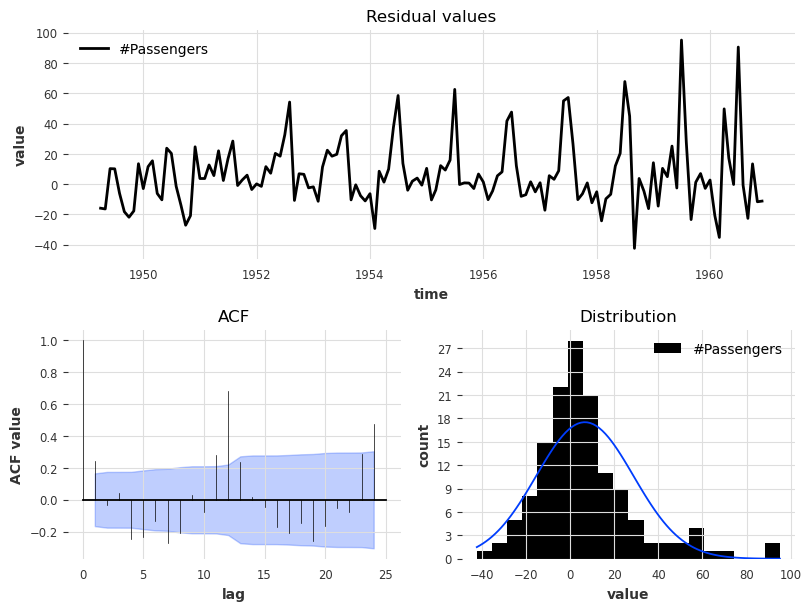

In [26]:
from darts.utils.statistics import plot_residuals_analysis

plot_residuals_analysis(best_theta_model.residuals(series))

# This gives analysis of residuals (difference between predicted and actual) that can be used to evaluate model
# performance.
# The distribution is not centered on zero, indicating bias.
# Autocoreelation lag spikes at 12 indicating that there are patterns the model is missing.

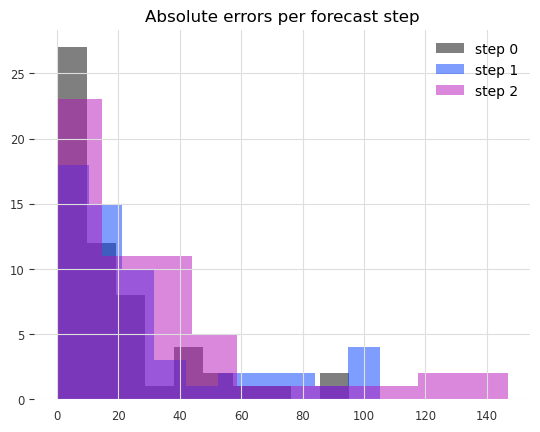

In [29]:
from darts.metrics import ae

# this returns an array of absolute error values for each step in each forecast
residuals = best_theta_model.residuals(historical_forecasts=hfc_precomputed,
                                       metric=ae,  #absolute error per time step
                                       last_points_only=False,
                                       values_only=True, # return a list of np arrays
                                       **hfc_params,
                                      )
# this is collecting all the residuals for each time step and restructures the data so they are grouped by columns, which corresponds to each predict step. axis=1 is telling numpy to concat by columns. The slice after is just removing unnecessary dimensions.
residuals = np.concatenate(residuals, axis=1)[:, :, 0]

fig, ax = plt.subplots()
# len(residuals) = forecast horizon
for forecast_step in range(len(residuals)):
    ax.hist(residuals[forecast_step], label=f"step {forecast_step}", alpha=0.5)
ax.legend()
ax.set_title("Absolute errors per forecast step");

# histogram indicates errors increase with each subsequent forecast step.

historical forecasts:   0%|          | 0/58 [00:00<?, ?it/s]

MAPE=4.42%


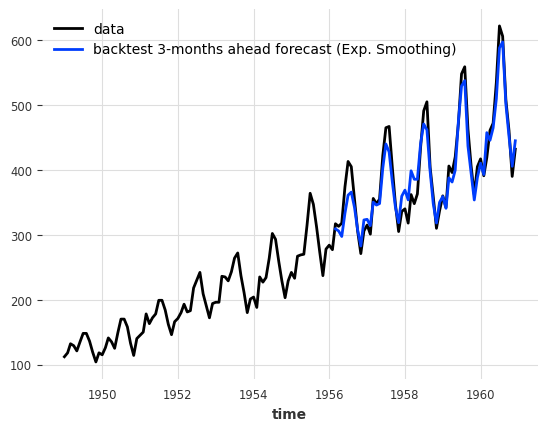

In [30]:
model_es = ExponentialSmoothing(seasonal_periods=12)
historical_fcast_es = model_es.historical_forecasts(**hfc_params)

series.plot(label='data')
historical_fcast_es.plot(label='backtest 3-months ahead forecast (Exp. Smoothing)')
print(f"MAPE={mape(historical_fcast_es, series):.2f}%")

historical forecasts:   0%|          | 0/120 [00:00<?, ?it/s]

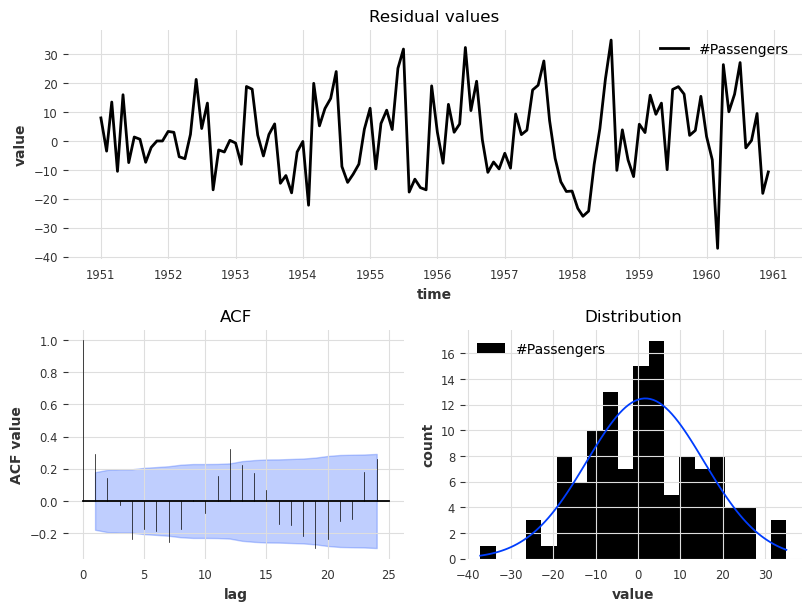

In [31]:
plot_residuals_analysis(model_es.residuals(series, verbose=True))

# residual analysis also shows improved statistics.
# distribution is more centered around zero, less bias.
# Autocorrelation values have smaller magnitude, means ExponentialSmoothing is capturing more patterns.

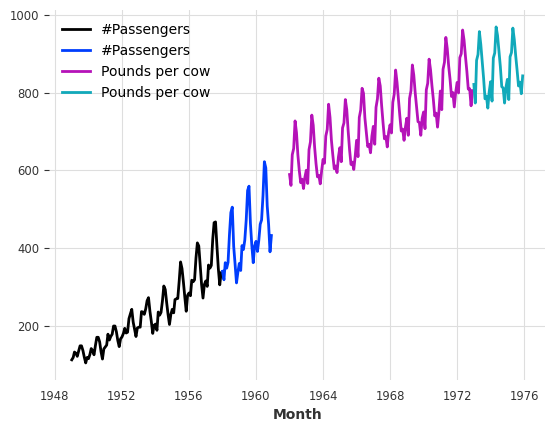

In [33]:
from darts.datasets import AirPassengersDataset, MonthlyMilkDataset

series_air = AirPassengersDataset().load().astype(np.float32)
series_milk = MonthlyMilkDataset().load().astype(np.float32)

# set aside last 36 months of each series as validation set
train_air, val_air = series_air[:-36], series_air[-36:]
train_milk, val_milk = series_milk[:-36], series_milk[-36:]

train_air.plot()
val_air.plot()
train_milk.plot()
val_milk.plot();


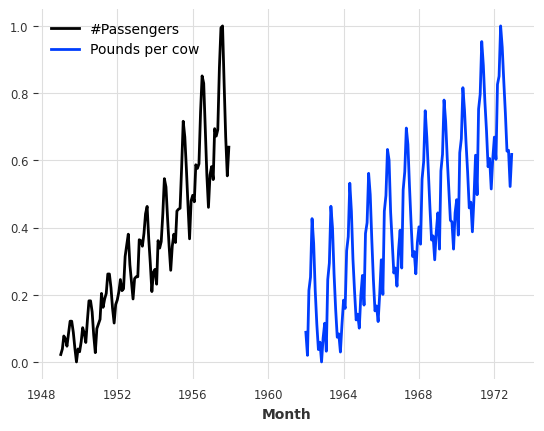

In [35]:
from darts.dataprocessing.transformers import Scaler

# scaling the training data to lie in [0,1] will make it easier for ML models
scaler = Scaler()
train_air_scaled, train_milk_scaled = scaler.fit_transform([train_air, train_milk])

train_air_scaled.plot()
train_milk_scaled.plot();

In [36]:
from darts.models import NBEATSModel

# input_chunk_length specifies how many time steps of history the neural network uses to forecast
# output_chunk_length specifies how many time steps of future values the neural network will output
model = NBEATSModel(input_chunk_length=24, output_chunk_length=12, random_state=42)

model.fit([train_air_scaled, train_milk_scaled], epochs=50, verbose=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3070 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.2 M  | train
---------

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


NBEATSModel(output_chunk_shift=0, generic_architecture=True, num_stacks=30, num_blocks=1, num_layers=4, layer_widths=256, expansion_coefficient_dim=5, trend_polynomial_degree=2, dropout=0.0, activation=ReLU, input_chunk_length=24, output_chunk_length=12, random_state=42)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

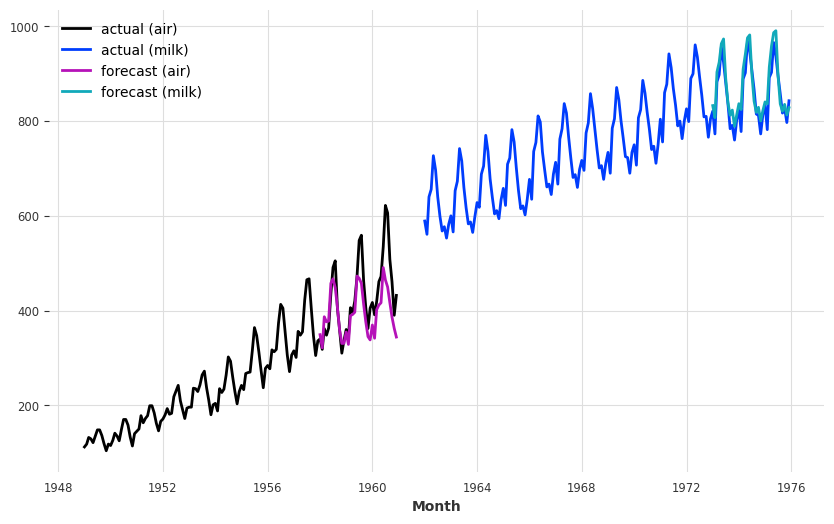

In [37]:
pred_air, pred_milk = model.predict(series=[train_air_scaled, train_milk_scaled], n=36)

# scale back
pred_air, pred_milk = scaler.inverse_transform([pred_air, pred_milk])

plt.figure(figsize=(10,6))
series_air.plot(label='actual (air)')
series_milk.plot(label='actual (milk)')
pred_air.plot(label='forecast (air)')
pred_milk.plot(label='forecast (milk)');


Text(0.5, 1.0, 'one multivariate time series of 2 dimensions, containing covariates for the air series:')

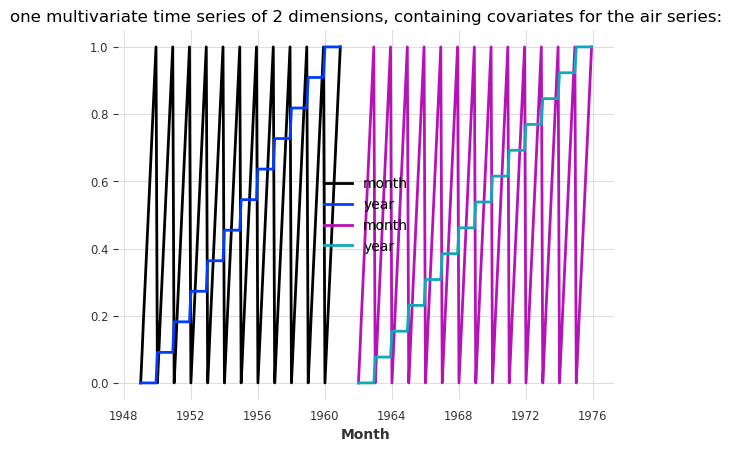

In [38]:
from darts import concatenate
from darts.utils.timeseries_generation import datetime_attribute_timeseries as dt_attr

air_covs = concatenate(
    [
        dt_attr(series_air, "month", dtype=np.float32),
        dt_attr(series_air, "year", dtype=np.float32),
    ],
    axis="component"
)

milk_covs = concatenate(
    [
        dt_attr(series_milk, "month", dtype=np.float32),
        dt_attr(series_milk, "year", dtype=np.float32),
    ],
    axis="component"
)

air_covs_scaled, milk_covs_scaled = Scaler().fit_transform([air_covs, milk_covs])
air_covs_scaled.plot()
milk_covs_scaled.plot()
plt.title(
    "one multivariate time series of 2 dimensions, containing covariates for the air series:"
)


In [40]:
model = NBEATSModel(input_chunk_length=24, output_chunk_length=12, random_state=42)

model.fit(
    [train_air_scaled, train_milk_scaled],
    past_covariates=[air_covs_scaled, milk_covs_scaled],
    epochs=50,
    verbose=True
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.6 M  | train
-------------------------------------------------------------
6.6 M     Trainable params
1.7 K     Non-trainable params
6.6 M     Total params
26.314    Total estimated model params size (MB)
396       Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


NBEATSModel(output_chunk_shift=0, generic_architecture=True, num_stacks=30, num_blocks=1, num_layers=4, layer_widths=256, expansion_coefficient_dim=5, trend_polynomial_degree=2, dropout=0.0, activation=ReLU, input_chunk_length=24, output_chunk_length=12, random_state=42)

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

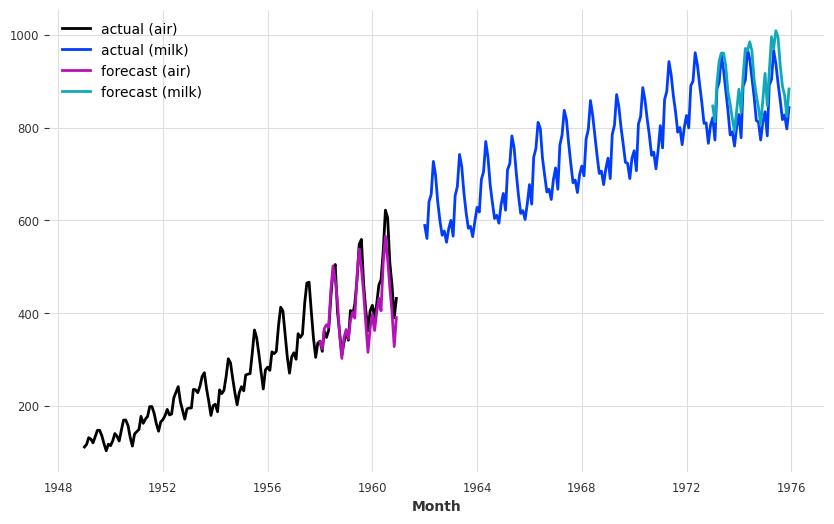

In [41]:
preds = model.predict(
    series=[train_air_scaled, train_milk_scaled],
    past_covariates=[air_covs_scaled, milk_covs_scaled],
    n=36,
)

pred_air, pred_milk = scaler.inverse_transform(preds)

plt.figure(figsize=(10,6))
series_air.plot(label='actual (air)')
series_milk.plot(label='actual (milk)')
pred_air.plot(label='forecast (air)')
pred_milk.plot(label='forecast (milk)');

In [42]:
# covariates related to the calendar or time axis are common so darts has a common method for using these for all models
def extract_year(idx):
    # extract the year for each time index entry and normalize it
    return (idx.year - 1950) / 50

# to accomplish the same results as above using encoders
encoders = {
    "datetime_attribute": {
        "past" : ["month", "year"]
    },
    "transformer": Scaler()
}

model = NBEATSModel(
    input_chunk_length=24,
    output_chunk_length=12,
    add_encoders=encoders,
    random_state=42
)

model.fit([train_air_scaled, train_milk_scaled], epochs=50, verbose=True);

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.6 M  | train
-------------------------------------------------------------
6.6 M     Trainable params
1.7 K     Non-trainable params
6.6 M     Total params
26.314    Total estimated model params size (MB)
396       Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

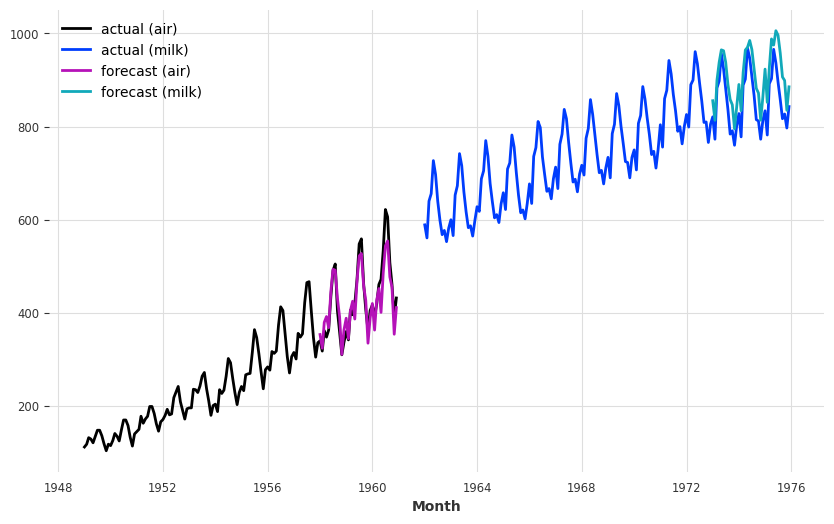

In [43]:
preds = model.predict(
    series=[train_air_scaled, train_milk_scaled],
    n=36,
    show_warnings=False
)

pred_air, pred_milk = scaler.inverse_transform(preds)
plt.figure(figsize=(10,6))
series_air.plot(label='actual (air)')
series_milk.plot(label='actual (milk)')
pred_air.plot(label='forecast (air)')
pred_milk.plot(label='forecast (milk)');

In [45]:
from sklearn.linear_model import BayesianRidge
from darts.models import RegressionModel

# lags=72 tells the model to look at the past 72 lags / months of the target.
# lags_future_covariates is telling the model should look at the 0th lag and the -6th
# lag of the provided future_covariates.
# the 0th lag is the current lag, or the timestamp currently being forecasted.
# the -6th lag is covariates of the past 6 months before the timestep being forecasted.
model = RegressionModel(lags=72, lags_future_covariates=[-6,0], model=BayesianRidge())

model.fit(
    [train_air_scaled, train_milk_scaled],
    future_covariates=[air_covs_scaled, milk_covs_scaled]
)

RegressionModel(lags=72, lags_past_covariates=None, lags_future_covariates=[-6, 0], output_chunk_length=1, output_chunk_shift=0, add_encoders=None, model=BayesianRidge(), multi_models=True, use_static_covariates=True)

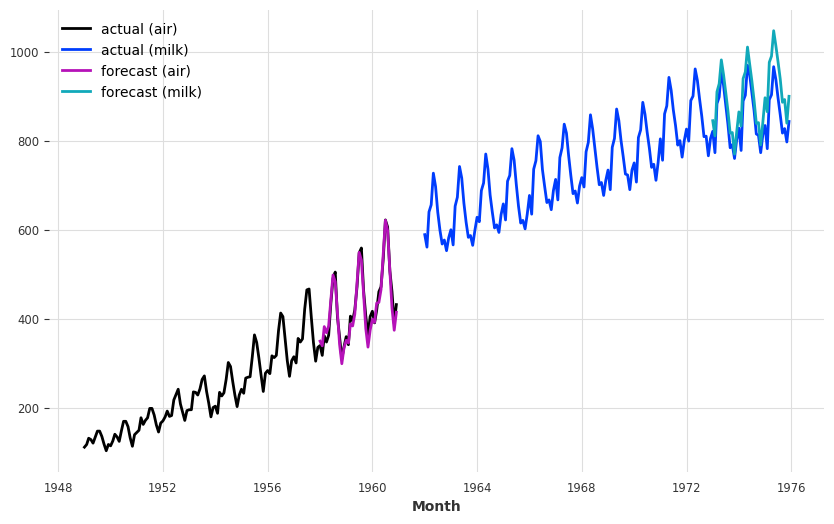

In [47]:
preds = model.predict(
    series=[train_air_scaled, train_milk_scaled],
    future_covariates=[air_covs_scaled, milk_covs_scaled],
    n=36
)

pred_air, pred_milk = scaler.inverse_transform(preds)

plt.figure(figsize=(10,6))
series_air.plot(label='actual (air)')
series_milk.plot(label='actual (milk)')
pred_air.plot(label='forecast (air)')
pred_milk.plot(label='forecast (milk)');

In [48]:
mape([series_air, series_milk], [pred_air, pred_milk])

[np.float32(3.4353676), np.float32(5.1291366)]

In [49]:
mape([series_air, series_milk], [pred_air, pred_milk], series_reduction=np.mean)


np.float32(4.2822523)

`enable_optimization=True` is ignored because `retrain` is not `False` or `0`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.
`enable_optimization=True` is ignored because `forecast_horizon > model.output_chunk_length`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.


historical forecasts:   0%|          | 0/58 [00:00<?, ?it/s]

MAPE = 3.76%


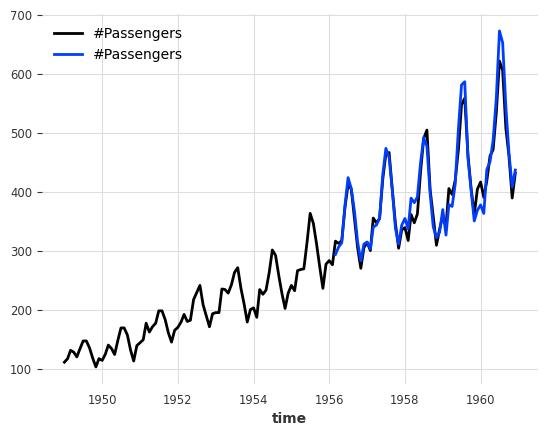

In [50]:
bayes_ridge_model = RegressionModel(
    lags=72, lags_future_covariates=[0], model=BayesianRidge()
)

backtest = bayes_ridge_model.historical_forecasts(
    future_covariates=[air_covs_scaled, milk_covs_scaled],
    **hfc_params
)

print(f"MAPE = {mape(series_air, backtest):.2f}%")
series_air.plot()
backtest.plot();

`enable_optimization=True` is ignored because `retrain` is not `False` or `0`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.
`enable_optimization=True` is ignored because `forecast_horizon > model.output_chunk_length`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.


historical forecasts:   0%|          | 0/58 [00:00<?, ?it/s]

MAPE = 3.92%


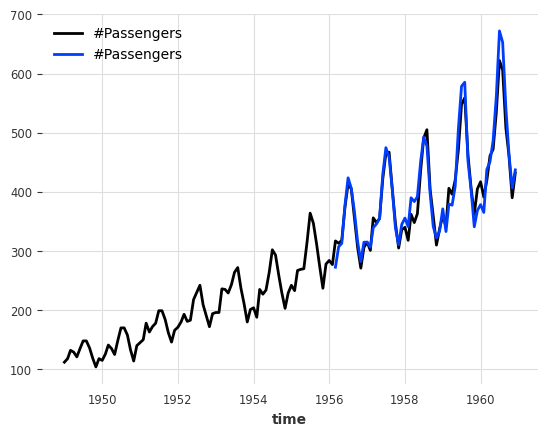

In [51]:
backtest_auto_scaling = bayes_ridge_model.historical_forecasts(
    future_covariates=air_covs,
    data_transformers={"series": Scaler(), "future_covariates": Scaler()},
    retrain=True,
    **hfc_params
)

print(f"MAPE = {mape(series_air, backtest_auto_scaling):.2f}%")
series_air.plot()
backtest_auto_scaling.plot();

historical forecasts:   0%|          | 0/57 [00:00<?, ?it/s]

MAPE = 26.40%


<Axes: xlabel='time'>

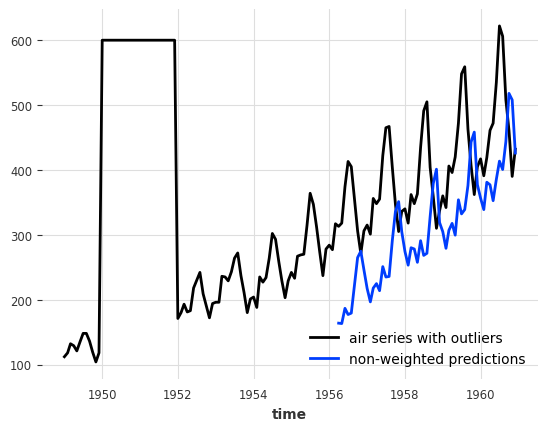

In [52]:
from darts.models import LinearRegressionModel

air_df = series_air.to_dataframe()
outlier_mask = (air_df.index.year >= 1950) & (air_df.index.year <= 1951)
air_df.loc[outlier_mask] = 600.0
air_outlier = TimeSeries.from_dataframe(air_df)

model_lin = LinearRegressionModel(lags=12, lags_future_covariates=[0])
hist_fc_kwargs = {
    "series": air_outlier,
    "future_covariates": air_covs_scaled,
    "start": 0.6,
    "forecast_horizon": 3,
    "verbose": True,
    "show_warnings": False
}
backtest = model_lin.historical_forecasts(**hist_fc_kwargs)

print(f"MAPE = {mape(air_outlier, backtest):.2f}%")
air_outlier.plot(label="air series with outliers")
backtest.plot(label="non-weighted predictions")

<Axes: xlabel='Month'>

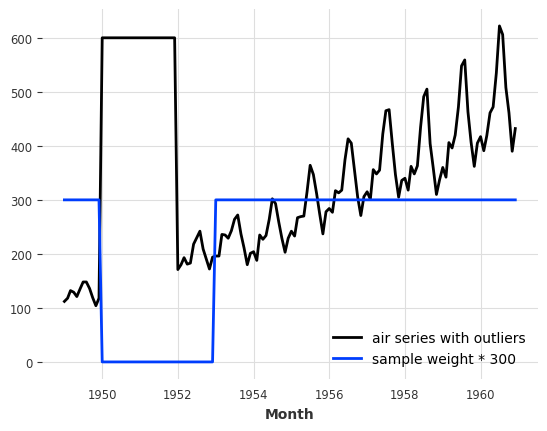

In [53]:
weight_mask = (air_df.index.year >= 1950) & (air_df.index.year <= 1952)
sample_weight = np.ones((len(air_df), 1))
sample_weight[weight_mask, 0] = 0.0
sample_weight = air_outlier.with_values(sample_weight)

air_outlier.plot(label="air series with outliers")
(sample_weight * 300).plot(label="sample weight * 300")

historical forecasts:   0%|          | 0/57 [00:00<?, ?it/s]

MAPE = 5.19%


<Axes: xlabel='time'>

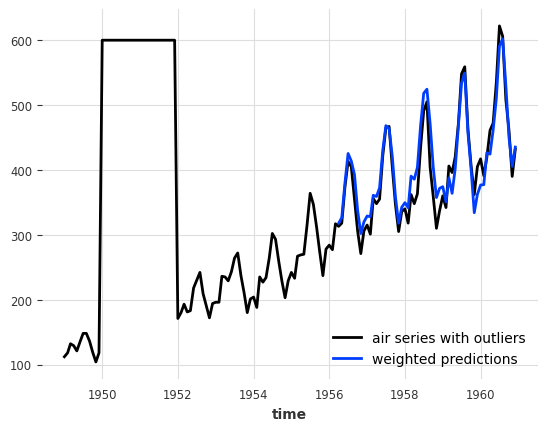

In [54]:
model_lin = LinearRegressionModel(lags=12, lags_future_covariates=[0])
backtest_weighted = model_lin.historical_forecasts(
    sample_weight=sample_weight, **hist_fc_kwargs
)

print(f"MAPE = {mape(series_air, backtest_weighted):.2f}%")
air_outlier.plot(label="air series with outliers")
backtest_weighted.plot(label="weighted predictions")

historical forecasts:   0%|          | 0/58 [00:00<?, ?it/s]

MAPE = 11.93%


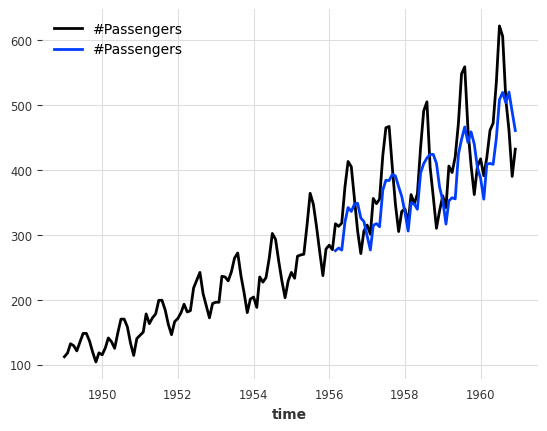

In [55]:
from darts.models import NaiveEnsembleModel

models = [NaiveDrift(), NaiveSeasonal(12)]
ensemble_model = NaiveEnsembleModel(forecasting_models=models)

backtest = ensemble_model.historical_forecasts(**hfc_params)

print(f"MAPE = {mape(backtest, series_air):.2f}%")
series_air.plot()
backtest.plot();

historical forecasts:   0%|          | 0/58 [00:00<?, ?it/s]

MAPE = 4.77


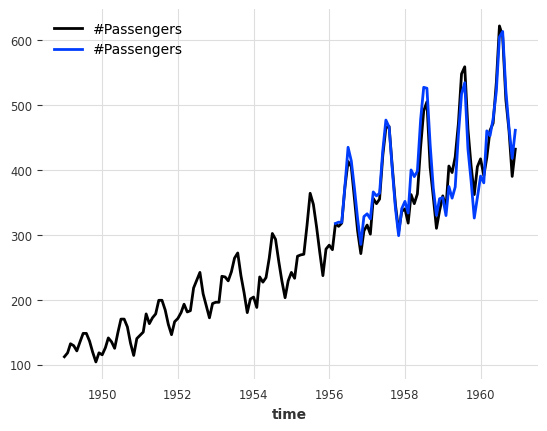

In [56]:
from darts.models import RegressionEnsembleModel

ensemble_model = RegressionEnsembleModel(
    forecasting_models=models, regression_train_n_points=12
)

backtest = ensemble_model.historical_forecasts(**hfc_params)

print(f"MAPE = {mape(backtest, series_air):.2f}")
series_air.plot()
backtest.plot();

In [57]:
ensemble_model.fit(series_air)
ensemble_model.regression_model.model.coef_

array([0.01368849, 1.0980105 ], dtype=float32)